In [1]:
# EXP1 = "G6sulfur"   # minuend
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"


In [2]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# User-defined metadata
# =========================

varname = "pr"
varname_T = "tas"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [3]:

# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    ds_in = da.to_dataset(name='data')
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means




# =========================
# Physical constants
# =========================
Cp = 1005.0    # J kg-1 K-1
Lv = 2.5e6     # J kg-1

# =========================
# Model/variable exceptions
# =========================
def get_var_name(vname, model_name):
    """Handle model-specific variable name exceptions."""
    if vname == "huss":
        if model_name in ("CNRM-ESM2-1", "MPI-ESM1-2-LR", "IPSL-CM6A-LR"):
            return "huss"
    return vname

all_results = {}

for model_name, model_meta in MODELS.items():

    var = {}
    var_by_year = {}

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():

        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_tas = make_base("tas")
        base_huss = make_base("huss")
        # base_huss = make_base(get_var_name("huss", model_name))  # handles huss for CNRM

        ######## ds for TAS ############
        print(str(base_tas))
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds_tas = mf.open_files_CESM_G6sulfur(base_tas)
            elif meta["scenario"] == "ssp585":
                ds_tas = mf.open_files_CESM_ssp585(base_tas)
            else:
                ds_tas = mf.open_files(str(base_tas))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds_tas = mf.open_files_IPSL_ssp585(base_tas)
            else:
                ds_tas = mf.open_files(str(base_tas))
        else:
            ds_tas = mf.open_files(str(base_tas))

        ######## ds for huss ############
        print(str(base_huss))
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds_huss = mf.open_files_CESM_G6sulfur(base_huss)
            elif meta["scenario"] == "ssp585":
                ds_huss = mf.open_files_CESM_ssp585(base_huss)
            else:
                ds_huss = mf.open_files(str(base_huss))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds_huss = mf.open_files_IPSL_ssp585(base_huss)
            else:
                ds_huss = mf.open_files(str(base_huss))
        else:
            ds_huss = mf.open_files(str(base_huss))
        ################################

        # # Read individual variables
        # da_tas = mf.read_var(ds_tas, "tas")
        # da_tas = da_tas.drop_vars("height", errors="ignore")
        # da_huss = mf.read_var(ds_huss, get_var_name("huss", model_name))  # handles huss   

        # Read individual variables
        da_tas = mf.read_var(ds_tas, "tas")
        # da_tas = da_tas.drop_vars("height", errors="ignore")
        da_huss = mf.read_var(ds_huss, get_var_name("huss", model_name))  # handles huss  
        da_huss = da_huss.drop_vars(["plev", "height"], errors="ignore")
        da_tas = da_tas.drop_vars(["plev", "height"], errors="ignore")

        print(f"  [{model_name}] {exp}: tas loaded {da_tas.sizes['time']} months "
              f"({da_tas.time.values[0]} → {da_tas.time.values[-1]})")
        print(f"  [{model_name}] {exp}: huss loaded {da_huss.sizes['time']} months "
              f"({da_huss.time.values[0]} → {da_huss.time.values[-1]})")

        # Compute MSEsfc = Cp*Tsfc + Lv*qsfc
        var[exp] = Cp * da_tas ;#T component of MSE
        var[exp].name = "MSEsfc"

        print(f"  [{model_name}] {exp}: MSEsfc computed, shape={var[exp].shape}")

    # ----------------------------
    # 2) SEASONAL MEANS BY YEAR       ← unchanged
    # ----------------------------
    for exp, da in var.items():
        t_start, t_end = _time_slice(exp)
        da_sliced = da.sel(time=slice(t_start, t_end))
        n_months = da_sliced.sizes['time']
        print(f"  [{model_name}] {exp}: sliced to {n_months} months = "
              f"{n_months//12} years "
              f"({da_sliced.time.values[0]} → {da_sliced.time.values[-1]})")

        var_by_year[exp] = {
            "SUM": mf.seasonal_mean_by_year_old(da_sliced, 6, 9),
            "WIN": mf.seasonal_mean_by_year_old(da_sliced, 11, 2),
            "ANN": mf.seasonal_mean_by_year_old(da_sliced, 1, 12)
        }

    # ----------------------------
    # 3) CLIMATOLOGY                  ← unchanged, but NO *86400 conversion
    # ----------------------------
    results = {}

    for exp in var_by_year:
        results[exp] = {}
        for season in ["SUM", "WIN", "ANN"]:
            da_year = var_by_year[exp][season]
            results[exp][season] = {
                "mean": da_year.mean(dim="year"),   # units: J/kg
                "sd":   da_year.std(dim="year"),
            }

    # # ----------------------------
    # # 4) Δbias                        ← unchanged
    # # ----------------------------
    # if EXP1 in results and EXP2 in results:
    #     delta = {}
    #     delta_sd = {}
    #     for season in ["SUM", "WIN", "ANN"]:
    #         delta[season]    = results[EXP1][season]["mean"] - results[EXP2][season]["mean"]
    #         delta_sd[season] = np.sqrt(results[EXP1][season]["sd"]**2 +
    #                                    results[EXP2][season]["sd"]**2)
    #     results["delta_bias"]    = delta
    #     results["delta_bias_sd"] = delta_sd

    # ----------------------------
    # 4) Δbias (Relative MSE calculation)
    # ----------------------------
    if EXP1 in results and EXP2 in results:
        delta = {}
        # delta_sd = {}

        for season in ["SUM", "WIN", "ANN"]:

            mean1 = results[EXP1][season]["mean"]
            mean2 = results[EXP2][season]["mean"]
            

            # --- Relative MSE: subtract tropical mean (30S-30N) ---
            weights = np.cos(np.deg2rad(mean1.lat))

            def trop_mean(da):
                da_trop  = da.sel(lat=slice(-30, 30))
                w_trop   = weights.sel(lat=slice(-30, 30))
                return (da_trop * w_trop).sum("lat") / w_trop.sum("lat")

            rel_mean1 = mean1 - trop_mean(mean1).mean("lon")
            rel_mean2 = mean2 - trop_mean(mean2).mean("lon")

            delta[season]    = rel_mean1 - rel_mean2
            # delta_sd[season] = np.sqrt(results[EXP1][season]["sd"]**2 +
            #                            results[EXP2][season]["sd"]**2)

        results["delta_bias"]    = delta
        results["rel_mean"]   = {}
        results["rel_mean"][EXP1] = {s: results[EXP1][s]["mean"] - trop_mean(results[EXP1][s]["mean"]).mean("lon") for s in ["SUM","WIN","ANN"]}
        results["rel_mean"][EXP2] = {s: results[EXP2][s]["mean"] - trop_mean(results[EXP2][s]["mean"]).mean("lon") for s in ["SUM","WIN","ANN"]}

    all_results[model_name] = results


/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/tas/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/huss/gn/latest
  [UKESM1-0-LL] G6sulfur: tas loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] G6sulfur: huss loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] G6sulfur: MSEsfc computed, shape=(972, 144, 192)
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/tas/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/huss/gn/latest
  [UKESM1-0-LL] SSP245: tas loaded 1032 months (2015-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] SSP245: huss loaded 1032 months (2015-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] SSP245: MSEsfc computed, shape=(1032, 144, 192)
  [UKESM1-0-LL] G6sulfur: sliced to 960 months = 80 years (2021-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] SSP245: sliced to 960 months = 80 years (

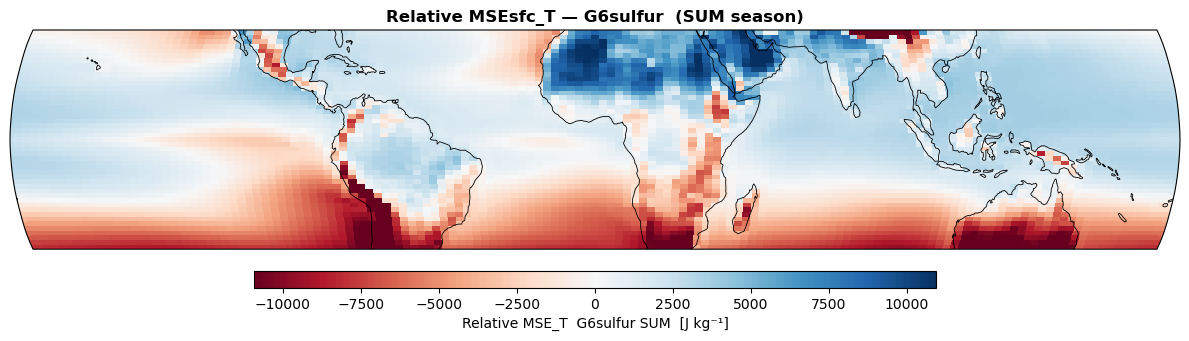

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

da = results["rel_mean"][EXP1]["SUM"].sel(lat=slice(-30,30))   # or "WIN" / "ANN"

fig, ax = plt.subplots(figsize=(12, 5),
                       subplot_kw={"projection": ccrs.Robinson()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

vmax = float(np.nanpercentile(np.abs(da.values), 98))

im = ax.pcolormesh(da.lon, da.lat, da,
                   cmap="RdBu", vmin=-vmax, vmax=vmax,
                   transform=ccrs.PlateCarree(),
                   shading="nearest")

plt.colorbar(im, ax=ax, orientation="horizontal",
             pad=0.05, fraction=0.04, aspect=40,
             label=f"Relative MSE_T  {EXP1} SUM  [J kg⁻¹]")
ax.set_title(f"Relative MSEsfc_T — {EXP1}  (SUM season)", fontweight="bold")
plt.tight_layout()
plt.show()

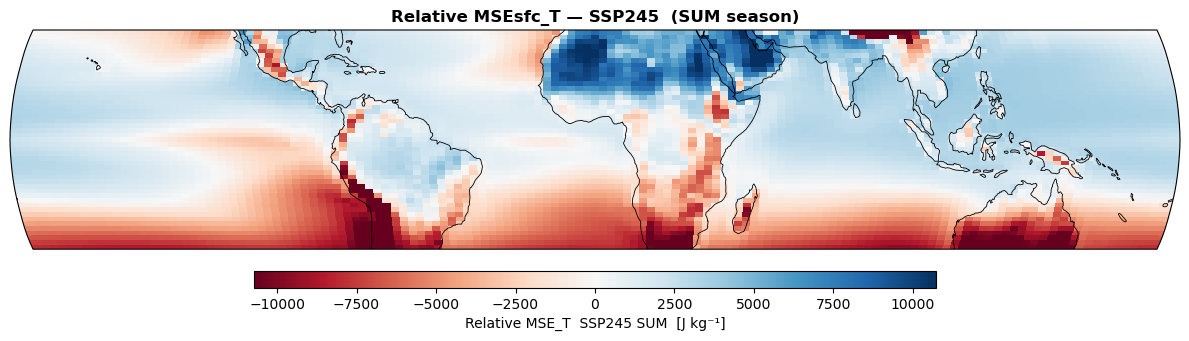

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

da = results["rel_mean"][EXP2]["SUM"].sel(lat=slice(-30,30))   # or "WIN" / "ANN"

fig, ax = plt.subplots(figsize=(12, 5),
                       subplot_kw={"projection": ccrs.Robinson()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

vmax = float(np.nanpercentile(np.abs(da.values), 98))

im = ax.pcolormesh(da.lon, da.lat, da,
                   cmap="RdBu", vmin=-vmax, vmax=vmax,
                   transform=ccrs.PlateCarree(),
                   shading="nearest")

plt.colorbar(im, ax=ax, orientation="horizontal",
             pad=0.05, fraction=0.04, aspect=40,
             label=f"Relative MSE_T  {EXP2} SUM  [J kg⁻¹]")
ax.set_title(f"Relative MSEsfc_T — {EXP2}  (SUM season)", fontweight="bold")
plt.tight_layout()
plt.show()

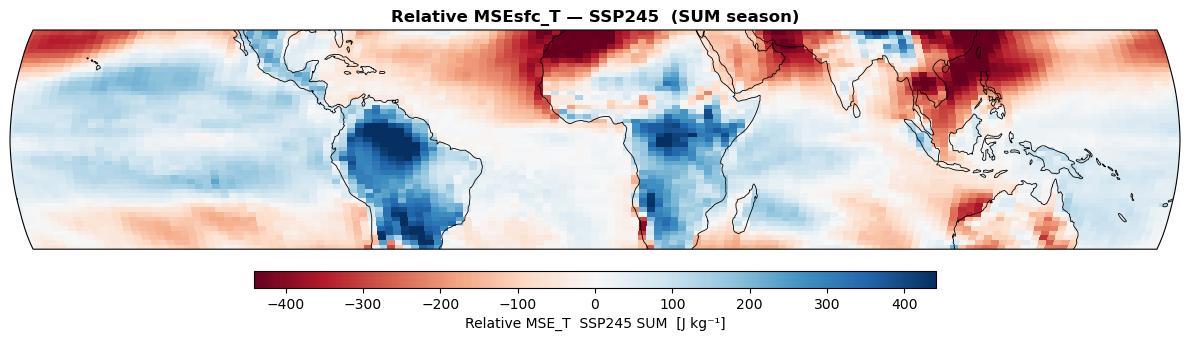

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

da = results["rel_mean"][EXP1]["WIN"].sel(lat=slice(-30,30)) - results["rel_mean"][EXP2]["WIN"].sel(lat=slice(-30,30))  # or "WIN" / "ANN"

fig, ax = plt.subplots(figsize=(12, 5),
                       subplot_kw={"projection": ccrs.Robinson()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

vmax = float(np.nanpercentile(np.abs(da.values), 98))

im = ax.pcolormesh(da.lon, da.lat, da,
                   cmap="RdBu", vmin=-vmax, vmax=vmax,
                   transform=ccrs.PlateCarree(),
                   shading="nearest")

plt.colorbar(im, ax=ax, orientation="horizontal",
             pad=0.05, fraction=0.04, aspect=40,
             label=f"Relative MSE_T  {EXP2} SUM  [J kg⁻¹]")
ax.set_title(f"Relative MSEsfc_T — {EXP2}  (SUM season)", fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
# ================================================================
# Main function
# ================================================================

def compute_regional_bar(
    all_results,
    exp1,
    exp2,
    trop_bound=30,
    land_mask=None,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    """
    Compute (and optionally plot) the regional bar data for (exp1 - exp2).

    Parameters
    ----------
    all_results : dict
        Top-level results dict keyed by model name.
        Each model must contain results[exp1] and results[exp2],
        each with seasons 'SUM' and 'WIN' containing 'mean' DataArrays.
    exp1, exp2 : str
        Experiment names, e.g. 'G6sulfur', 'SSP585', 'SSP245', 'HIST'.
        Time slicing is determined automatically from the experiment name.
    trop_bound : int
        Tropical latitude boundary (degrees). Default 30.
    land_mask : xarray.DataArray or None
        Boolean land mask. If None, built from regionmask.
    plot : bool
        Whether to display the bar chart. Default True.
    save_fig : bool
        Whether to save the figure. Default False.
    fig_path : str or None
        Path for saved figure. Auto-generated if None and save_fig=True.

    Returns
    -------
    bar_data : dict
        Keys: 'labels', 'means', 'colors', 'per_model_all'.
        Stored in the caller's namespace as
        bar_data_{exp1}{y1}_minus_{exp2}{y2}.
    var_name : str
        The variable name string (so you know what to look up in the dict).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import xarray as xr
    import warnings

    label1 = _exp_year_label(exp1)
    label2 = _exp_year_label(exp2)
    var_name = f"MSEsfc_T_bar_data_{exp1}{label1}_minus_{exp2}{label2}"
    t1 = _time_slice(exp1)
    t2 = _time_slice(exp2)

    # ------------------------------------------------------------------ #
    # 1.  Build per-model delta fields (exp1 - exp2)
    # ------------------------------------------------------------------ #
    delta_list = []

    for model_name, results in all_results.items():
            if "rel_mean" not in results:
                warnings.warn(f"Model '{model_name}' has no 'rel_mean' — skipped.")
                continue
            if exp1 not in results["rel_mean"] or exp2 not in results["rel_mean"]:
                warnings.warn(f"Model '{model_name}' missing rel_mean for '{exp1}' or '{exp2}' — skipped.")
                continue
    
            delta_by_season = {}
            for season in ("SUM", "WIN"):
                mean1 = results["rel_mean"][exp1][season]
                mean2 = results["rel_mean"][exp2][season]
                delta_by_season[season] = mean1 - mean2
    
            da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
            da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))
    
            lat      = da_SUM.lat
            stitched = xr.where(lat > 0, da_SUM, da_WIN)
            delta_list.append(stitched)

    if not delta_list:
        raise ValueError(f"No models with both '{exp1}' and '{exp2}' found.")

    stacked = xr.concat(delta_list, dim="model")        # (model, lat, lon)
    lat     = stacked.lat.values
    lon     = stacked.lon.values

    # DEBUG
    print(float(stacked.mean("model").sel(lat=slice(15,27), lon=slice(73,87)).mean()))
    # ------------------------------------------------------------------ #
    # 2.  Land / ocean mask
    # ------------------------------------------------------------------ #
    if land_mask is None:
        try:
            import regionmask
            land_110     = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            mask_np      = land_110.mask(lon, lat)
            land_mask_da = xr.DataArray(~np.isnan(mask_np.values),
                                        dims=["lat", "lon"],
                                        coords={"lat": lat, "lon": lon})
        except ImportError:
            warnings.warn("regionmask not found — using all-ocean proxy.")
            land_mask_da = xr.DataArray(np.zeros((len(lat), len(lon)), dtype=bool),
                                        dims=["lat", "lon"],
                                        coords={"lat": lat, "lon": lon})
    else:
        land_mask_da = land_mask.interp(lat=lat, lon=lon, method="nearest") > 0.5

    ocean_mask_da = ~land_mask_da

    # ------------------------------------------------------------------ #
    # 3.  Monsoon region boxes
    # ------------------------------------------------------------------ #
    regions = {
        "N. America":   {"lon": (248, 258),   "lat": (18,    33)},
        "S. America":   {"lon": (300, 318),   "lat": (-18.5, -7)},
        "Sahel":        {"lon": (0,   40),    "lat": (7,   18.5)},
        "S. Africa":    {"lon": (19.5, 31),   "lat": (-18.5, -7)},
        "India":        {"lon": (73,  87),    "lat": (15,    27)},
        "N. Australia": {"lon": (120.5, 149), "lat": (-21,  -9.5)},
    }

    # ------------------------------------------------------------------ #
    # 4.  Area-weighted means
    # ------------------------------------------------------------------ #
    weights    = np.cos(np.deg2rad(lat))
    weights_da = xr.DataArray(weights, dims=["lat"], coords={"lat": lat})

    def area_mean(data_3d, mask_2d):
        masked = data_3d.where(mask_2d)
        w      = weights_da.where(mask_2d)
        return (masked * w).sum(["lat", "lon"]) / w.sum(["lat", "lon"])

    def to_180(l):
        return ((l + 180) % 360) - 180

    def box_mask(lon_range, lat_range):
        lon0, lon1 = to_180(lon_range[0]), to_180(lon_range[1])
        lat0, lat1 = lat_range
        lon_da, lat_da = stacked.lon, stacked.lat
        if lon0 <= lon1:
            lon_sel = (lon_da >= lon0) & (lon_da <= lon1)
        else:
            lon_sel = (lon_da >= lon0) | (lon_da <= lon1)
        return lon_sel & (lat_da >= lat0) & (lat_da <= lat1)

    # ── DEBUG ──────────────────────────────────────────────────────────
    india_val = float(stacked.mean("model").sel(lat=slice(15,27), lon=slice(73,87)).mean())
    print(f"India raw stacked mean: {india_val:.4f}")
    bmask_india = box_mask((73, 87), (15, 27))
    india_bar   = float(area_mean(stacked, bmask_india).mean())
    print(f"India area_mean result: {india_bar:.4f}")
    # ───────────────────────────────────────────────────────────────────

    labels        = []
    means         = []
    colors        = []
    per_model_all = []

    land_ocean = [("Land",  land_mask_da,  "#E07B3A"),
                  ("Ocean", ocean_mask_da, "#3A7BE0")]
    region_colors = ["#D45F8B", "#8B5FD4", "#5FD4A0",
                     "#D4A05F", "#5FAFD4", "#A0D45F"]

    for label, mask, color in land_ocean:
        pm = area_mean(stacked, mask).values
        labels.append(label)
        means.append(float(np.nanmean(pm)))
        colors.append(color)
        per_model_all.append(pm)

    for (rname, coords), rcol in zip(regions.items(), region_colors):
        bmask = box_mask(coords["lon"], coords["lat"])
        pm    = area_mean(stacked, bmask).values
        labels.append(rname)
        means.append(float(np.nanmean(pm)))
        colors.append(rcol)
        per_model_all.append(pm)

    means = np.array(means)
    x     = np.arange(len(labels))

    # ------------------------------------------------------------------ #
    # 5.  Plot (optional)
    # ------------------------------------------------------------------ #
    fig = None
    if plot:
        fig, ax = plt.subplots(figsize=(11, 5))

        ax.bar(x, means, color=colors, edgecolor="k",
               linewidth=0.7, alpha=0.85, zorder=3)

        rng      = np.random.default_rng(42)
        n_models = len(delta_list)
        for i, pm in enumerate(per_model_all):
            jitter = rng.uniform(-0.18, 0.18, size=len(pm))
            ax.scatter(np.full(len(pm), x[i]) + jitter, pm,   # ← np.full instead of x[i]
                       color="k", s=20,
                       zorder=5, alpha=0.6, linewidths=0.4, edgecolors="white")

        ax.axhline(0, color="k", linewidth=0.8, linestyle="--", zorder=2)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel(
            f"$\\Delta$ Relative MSE$_{{({exp1} - {exp2})}}$ [J kg$^{{-1}}$]",
            fontsize=10)
        ax.set_title(
            f"Multi-model mean $\\Delta$ precip response\n"
            f"({exp1} − {exp2})  |  NH: JJAS, SH: NDJF  |  "
            f"dots = individual models ({n_models} models)",
            fontsize=11)
        ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7, zorder=1)

        legend_patches = [
            mpatches.Patch(color="#E07B3A", label="Land"),
            mpatches.Patch(color="#3A7BE0", label="Ocean"),
            mpatches.Patch(color="grey",    label="Monsoon regions"),
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="k",
                       markersize=6, alpha=0.6, label="Individual models"),
        ]
        ax.legend(handles=legend_patches, fontsize=9, loc="upper right")
        # ax.set_ylim(-0.6, 1.30)
        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    # ------------------------------------------------------------------ #
    # 6.  Package and return
    # ------------------------------------------------------------------ #
    bar_data = {
        "labels":        labels,
        "means":         means,
        "colors":        colors,
        "per_model_all": per_model_all,
    }

    print(f"Returning → {var_name}")
    return bar_data, var_name





In [8]:
def compute_regional_map(
    all_results,
    exp1,
    exp2,
    trop_bound=50,
    land_mask=None,
    agreement_threshold=3,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import cartopy.io.shapereader as shpreader
    import xarray as xr
    import warnings
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

    label1   = _exp_year_label(exp1)
    label2   = _exp_year_label(exp2)
    var_name = f"MSEsfc_T_map_{exp1}{label1}_minus_{exp2}{label2}"

    # ------------------------------------------------------------------ #
    # 1.  Build per-model delta fields (exp1 - exp2)
    # ------------------------------------------------------------------ #
    delta_list = []

    for model_name, results in all_results.items():
        if "rel_mean" not in results:
            warnings.warn(f"Model '{model_name}' has no 'rel_mean' — skipped.")
            continue
        if exp1 not in results["rel_mean"] or exp2 not in results["rel_mean"]:
            warnings.warn(f"Model '{model_name}' missing rel_mean for '{exp1}' or '{exp2}' — skipped.")
            continue

        delta_by_season = {}
        for season in ("SUM", "WIN"):
            mean1 = results["rel_mean"][exp1][season]
            mean2 = results["rel_mean"][exp2][season]
            delta_by_season[season] = mean1 - mean2

        da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))

        lat      = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)   # NH=SUM, SH=WIN
        delta_list.append(stitched)

    if not delta_list:
        raise ValueError(f"No models with rel_mean for both '{exp1}' and '{exp2}' found.")

    n_models = len(delta_list)
    stacked  = xr.concat(delta_list, dim="model")

    # ------------------------------------------------------------------ #
    # 2.  Multi-model mean and stippling mask
    # ------------------------------------------------------------------ #

    delta_mean = stacked.mean(dim="model").squeeze()

    sign_mean    = np.sign(delta_mean.values)
    sign_models  = np.sign(stacked.values)
    n_agree      = np.sum(sign_models == sign_mean[np.newaxis, :, :], axis=0)
    stipple_mask = n_agree >= agreement_threshold

    lat  = delta_mean.lat.values
    lon  = delta_mean.lon.values
    data = delta_mean.values
    LON, LAT = np.meshgrid(lon, lat)

    # ------------------------------------------------------------------ #
    # 3.  Plot
    #     fig, ax = plt.subplots(1, 1, figsize=(10, 5),
    #                        subplot_kw={'projection': ccrs.PlateCarree(0)})
    # ax.add_feature(cfeature.COASTLINE, linewidth=0.3)

    # vmax   = 0.5
    # levels = np.linspace(-vmax, vmax, 21)
    # im = ax.contourf(lon, lat, mm_stitched, levels=levels, cmap='RdBu_r',
    #                  extend='both', transform=ccrs.PlateCarree())
    # ------------------------------------------------------------------ #
    if plot:
        vmax = float(np.nanpercentile(np.abs(data), 98))
        vmin = -vmax
        levels = np.linspace(-vmax, vmax, 21)

        # fig, ax = plt.subplots(figsize=(14, 5))
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        fig, ax = plt.subplots(figsize=(10, 5),
                               subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.set_global()
        # then pcolormesh with transform=ccrs.PlateCarree(), shading="nearest"

        # im = ax.pcolormesh(LON, LAT, data,
        #                    cmap="RdBu_r", vmin=vmin, vmax=vmax,
        #                    shading="nearest")
        im = ax.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())

        # Stippling
        stip_lat_flat = LAT[stipple_mask].ravel()[::2]
        stip_lon_flat = LON[stipple_mask].ravel()[::2]
        ax.scatter(stip_lon_flat, stip_lat_flat,
                   s=1.5, color="black", alpha=0.5, zorder=5)

        # Coastlines
        try:
            shpfilename = shpreader.natural_earth(
                resolution="110m", category="physical", name="coastline"
            )
            reader = shpreader.Reader(shpfilename)
            for geom in reader.geometries():
                if hasattr(geom, "geoms"):
                    for g in geom.geoms:
                        ax.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
                else:
                    ax.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
        except Exception:
            pass

        # cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
        #                     pad=0.08, fraction=0.04, aspect=40)
        
        cbar = plt.colorbar(im, ax=ax, orientation="horizontal", 
                            pad=0.05, shrink=1.0, aspect=40)

        cbar.set_label(f"Δ Relative MSE_T  ({exp1} − {exp2})  [J kg⁻¹]", fontsize=10)


        ###########################
        # Equator line
        ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
        ax.set_extent([float(lon.min()), float(lon.max()),
                       float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
        ax.set_aspect('auto')
    
        ax.set_xticks(np.arange(np.floor(float(lon.min())),
                                np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(np.floor(float(lat.min())),
                                np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=8)
        #############################

        
        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
        # ax.set_xlabel("Longitude", fontsize=9)
        # ax.set_ylabel("Latitude",  fontsize=9)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
        ax.set_title(
            f"Multi-model mean Δ Relative MSE_T  ({exp1} − {exp2})\n"
            f"NH: JJAS, SH: NDJF  |  "
            f"stippling = {agreement_threshold}/{n_models} model sign agreement",
            fontsize=11
        )
        ax.grid(True, linewidth=0.3, alpha=0.4)


        
        # Bombardi and Boos 2021 regions
        # Bombardi and Boos 2021 regions
        regions = {
            'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
            'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
            'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
            'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
            'India':        {'lon': (73,  87),   'lat': (15,    27)},
            'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
        }
        for name, coords in regions.items():
            lon0, lon1 = coords['lon']
            lat0, lat1 = coords['lat']
            rect = mpatches.Rectangle(
                (lon0, lat0), lon1-lon0, lat1-lat0,
                linewidth=1.2, edgecolor='black', facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax.add_patch(rect)
            ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
                    fontsize=8, ha='center', va='top',
                    transform=ccrs.PlateCarree())

        
        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    print(f"Returning → {var_name}")
    return delta_mean, stipple_mask

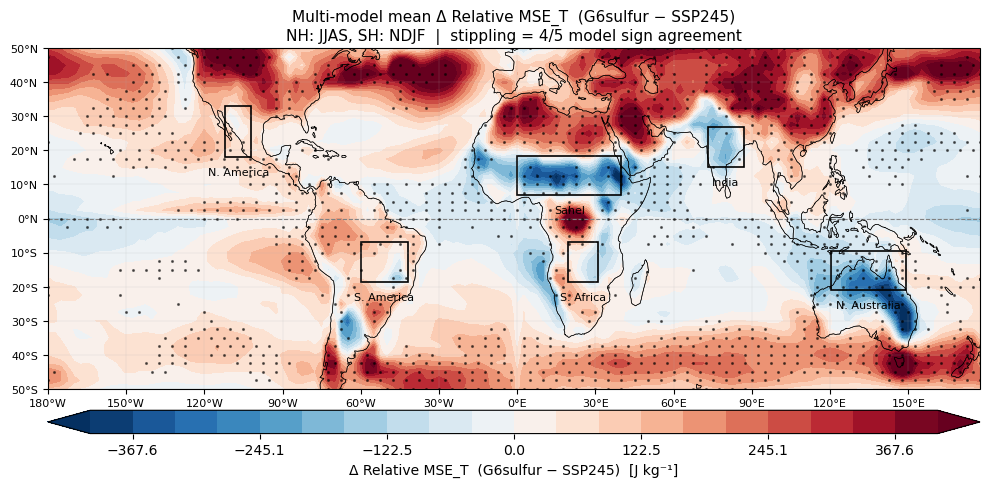

Figure saved → MSEsfc_T_map_G6sulfur20212100_minus_SSP24520212100.png
Returning → MSEsfc_T_map_G6sulfur20212100_minus_SSP24520212100


In [9]:
delta_mean, stipple_mask = compute_regional_map(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    agreement_threshold=4,   # 3/4 models
    save_fig=True
)

In [10]:
# # In[5]:
# import pickle
# from pathlib import Path

# SAVE_DIR = Path('/home/users/bidyut/UoE/20260218_Monsoons')
# pkl_path = SAVE_DIR / 'all_bar_data.pkl'

# # Load existing or start fresh
# if pkl_path.exists():
#     with open(pkl_path, 'rb') as f:
#         all_bar_data = pickle.load(f)
# else:
#     all_bar_data = {}

# # Compute once
# bar_data, name = compute_regional_bar(all_results, EXP1, EXP2, plot=False)
# all_bar_data[name] = bar_data

# # Save
# with open(pkl_path, 'wb') as f:
#     pickle.dump(all_bar_data, f)
# print(f"All keys now: {list(all_bar_data.keys())}")

# ###END

-130.7728173029216
India raw stacked mean: -130.7728
India area_mean result: -130.4705


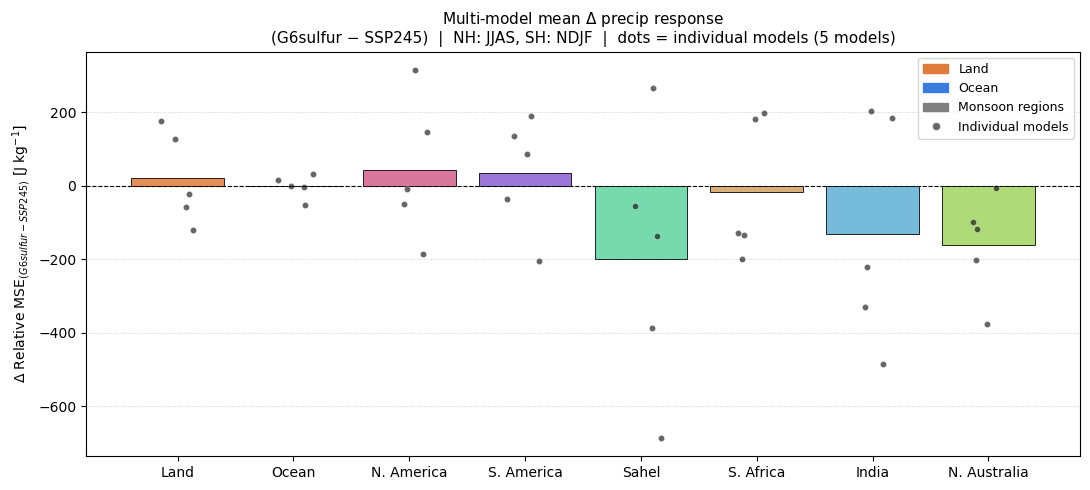

Returning → MSEsfc_T_bar_data_G6sulfur20212100_minus_SSP24520212100


In [11]:
# G6sulfur (2071-2100) minus SSP585 (2071-2100)
# bar_data, name = compute_regional_bar(all_results, "G6sulfur", "SSP585")
bar_data, name = compute_regional_bar(all_results, EXP1, EXP2)
# globals()[name] = bar_data     # stores as bar_data_G6sulfur20712100_minus_SSP58520712100

In [12]:
# %store bar_data_SSP58520212100_minus_HIST19212000

In [13]:
def compute_regional_map_with_zonal_mean(
    all_results,
    exp1,
    exp2,
    trop_bound=50,
    land_mask=None,
    agreement_threshold=3,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import cartopy.io.shapereader as shpreader
    import xarray as xr
    import warnings
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

    label1   = _exp_year_label(exp1)
    label2   = _exp_year_label(exp2)
    var_name = f"MSE_T_map_with_line_{exp1}{label1}_minus_{exp2}{label2}"

    # ------------------------------------------------------------------ #
    # 1.  Build per-model delta fields (exp1 - exp2)
    # ------------------------------------------------------------------ #
    delta_list = []
    mean1_list = []  # Store mean1 for each model
    mean2_list = []  # Store mean2 for each model

    for model_name, results in all_results.items():
        if "rel_mean" not in results:
            warnings.warn(f"Model '{model_name}' has no 'rel_mean' — skipped.")
            continue
        if exp1 not in results["rel_mean"] or exp2 not in results["rel_mean"]:
            warnings.warn(f"Model '{model_name}' missing rel_mean for '{exp1}' or '{exp2}' — skipped.")
            continue

        # Check if absolute mean data exists for line plot
        has_mean = (exp1 in results and exp2 in results and 
                    isinstance(results[exp1], dict) and isinstance(results[exp2], dict))

        delta_by_season = {}
        mean1_by_season = {}
        mean2_by_season = {}
        
        for season in ("SUM", "WIN"):
            # For map: use rel_mean
            rel_mean1 = results["rel_mean"][exp1][season]
            rel_mean2 = results["rel_mean"][exp2][season]
            delta_by_season[season] = rel_mean1 - rel_mean2
            
            # For line plot: use absolute mean from exp1[season]['mean']
            if has_mean and season in results[exp1] and season in results[exp2]:
                if 'mean' in results[exp1][season] and 'mean' in results[exp2][season]:
                    mean1_by_season[season] = results[exp1][season]['mean']
                    mean2_by_season[season] = results[exp2][season]['mean']

        da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))
        
        lat = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)   # NH=SUM, SH=WIN
        delta_list.append(stitched)
        
        # Only add to mean lists if mean data is available
        if len(mean1_by_season) == 2:  # Both SUM and WIN available
            # Also regrid mean1 and mean2 for line plot
            mean1_SUM = roll_lon(regrid_to_common(mean1_by_season["SUM"], target_lat=trop_bound))
            mean1_WIN = roll_lon(regrid_to_common(mean1_by_season["WIN"], target_lat=trop_bound))
            mean2_SUM = roll_lon(regrid_to_common(mean2_by_season["SUM"], target_lat=trop_bound))
            mean2_WIN = roll_lon(regrid_to_common(mean2_by_season["WIN"], target_lat=trop_bound))
            
            stitched_mean1 = xr.where(lat > 0, mean1_SUM, mean1_WIN)
            stitched_mean2 = xr.where(lat > 0, mean2_SUM, mean2_WIN)
            
            mean1_list.append(stitched_mean1)
            mean2_list.append(stitched_mean2)

    if not delta_list:
        raise ValueError(f"No models with rel_mean for both '{exp1}' and '{exp2}' found.")

    n_models = len(delta_list)
    stacked  = xr.concat(delta_list, dim="model")
    
    # Only create stacked mean arrays if we have mean data
    has_mean_data = len(mean1_list) > 0
    if has_mean_data:
        stacked_mean1 = xr.concat(mean1_list, dim="model")
        stacked_mean2 = xr.concat(mean2_list, dim="model")

    # ------------------------------------------------------------------ #
    # 2.  Multi-model mean and stippling mask
    # ------------------------------------------------------------------ #

    delta_mean = stacked.mean(dim="model").squeeze()
    if has_mean_data:
        ensemble_mean1 = stacked_mean1.mean(dim="model").squeeze()
        ensemble_mean2 = stacked_mean2.mean(dim="model").squeeze()

    sign_mean    = np.sign(delta_mean.values)
    sign_models  = np.sign(stacked.values)
    n_agree      = np.sum(sign_models == sign_mean[np.newaxis, :, :], axis=0)
    stipple_mask = n_agree >= agreement_threshold

    lat  = delta_mean.lat.values
    lon  = delta_mean.lon.values
    data = delta_mean.values
    LON, LAT = np.meshgrid(lon, lat)

    # ------------------------------------------------------------------ #
    # 3.  Plot
    # ------------------------------------------------------------------ #
    if plot:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        import matplotlib.patches as mpatches
        
        # Create figure with GridSpec for width ratio control
        from matplotlib.gridspec import GridSpec
        
        # Adjust figure layout based on whether we have mean data
        if has_mean_data:
            fig = plt.figure(figsize=(14, 5))
            gs = GridSpec(1, 2, figure=fig, width_ratios=[5, 1], wspace=0.25)
            ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
        else:
            fig = plt.figure(figsize=(10, 5))
            ax1 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        
        vmax = float(np.nanpercentile(np.abs(data), 98))
        vmin = -vmax
        levels = np.linspace(-vmax, vmax, 21)

        ax1.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax1.set_global()

        im = ax1.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())

        # Stippling
        stip_lat_flat = LAT[stipple_mask].ravel()[::2]
        stip_lon_flat = LON[stipple_mask].ravel()[::2]
        ax1.scatter(stip_lon_flat, stip_lat_flat,
                   s=1.5, color="black", alpha=0.5, zorder=5)

        # Coastlines
        try:
            shpfilename = shpreader.natural_earth(
                resolution="110m", category="physical", name="coastline"
            )
            reader = shpreader.Reader(shpfilename)
            for geom in reader.geometries():
                if hasattr(geom, "geoms"):
                    for g in geom.geoms:
                        ax1.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
                else:
                    ax1.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
        except Exception:
            pass

        cbar = plt.colorbar(im, ax=ax1, orientation="horizontal", 
                            pad=0.05, shrink=1.0, aspect=40)
        cbar.set_label(f"Δ Relative MSE_T  ({exp1} − {exp2})  [J kg⁻¹]", fontsize=10)

        # Equator line
        ax1.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
        ax1.set_extent([float(lon.min()), float(lon.max()),
                       float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
        ax1.set_aspect('auto')
    
        ax1.set_xticks(np.arange(np.floor(float(lon.min())),
                                np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
        ax1.set_yticks(np.arange(np.floor(float(lat.min())),
                                np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
        ax1.xaxis.set_major_formatter(LongitudeFormatter())
        ax1.yaxis.set_major_formatter(LatitudeFormatter())
        ax1.tick_params(labelsize=8)
        
        ax1.set_xlim(lon.min(), lon.max())
        ax1.set_ylim(lat.min(), lat.max())
        ax1.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
        ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
        ax1.set_title(
            f"Multi-model mean Δ Relative MSE_T  ({exp1} − {exp2})\n"
            f"NH: JJAS, SH: NDJF  |  "
            f"stippling = {agreement_threshold}/{n_models} model sign agreement",
            fontsize=11
        )
        ax1.grid(True, linewidth=0.3, alpha=0.4)

        # Bombardi and Boos 2021 regions
        regions = {
            'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
            'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
            'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
            'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
            'India':        {'lon': (73,  87),   'lat': (15,    27)},
            'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
        }
        for name, coords in regions.items():
            lon0, lon1 = coords['lon']
            lat0, lat1 = coords['lat']
            rect = mpatches.Rectangle(
                (lon0, lat0), lon1-lon0, lat1-lat0,
                linewidth=1.2, edgecolor='black', facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax1.add_patch(rect)
            ax1.text(lon0+(lon1-lon0)/2, lat0-3, name,
                    fontsize=8, ha='center', va='top',
                    transform=ccrs.PlateCarree())

        # ------------------------------------------------------------------ #
        # Right subplot: Zonal mean line plot (only if mean data available)
        # ------------------------------------------------------------------ #
        if has_mean_data:
            # Create ax2 in the gridspec position first
            ax2 = fig.add_subplot(gs[0, 1])
            
            # Force a draw to get ax1 position
            fig.canvas.draw()
            
            # Get the position of ax1 (the map axes, not including colorbar)
            ax1_pos = ax1.get_position()
            
            # Set ax2 to match ax1's vertical position and height
            ax2_pos = ax2.get_position()
            ax2.set_position([ax2_pos.x0, ax1_pos.y0, ax2_pos.width, ax1_pos.height])
            
            # Compute zonal means for individual models (convert to kJ)
            n_mean_models = len(mean1_list)
            for i in range(n_mean_models):
                zonal_mean1 = stacked_mean1.isel(model=i).mean(dim='lon') / 1000.0  # J to kJ
                zonal_mean2 = stacked_mean2.isel(model=i).mean(dim='lon') / 1000.0  # J to kJ
                
                ax2.plot(zonal_mean1, lat, color='red', alpha=0.3, linewidth=0.8)
                ax2.plot(zonal_mean2, lat, color='blue', alpha=0.3, linewidth=0.8)
            
            # Compute and plot ensemble means (thick lines, convert to kJ)
            zonal_ensemble_mean1 = ensemble_mean1.mean(dim='lon') / 1000.0  # J to kJ
            zonal_ensemble_mean2 = ensemble_mean2.mean(dim='lon') / 1000.0  # J to kJ
            
            ax2.plot(zonal_ensemble_mean1, lat, color='red', linewidth=2.5, 
                    label=f'{exp1}')
            ax2.plot(zonal_ensemble_mean2, lat, color='blue', linewidth=2.5, 
                    label=f'{exp2}')
            
            ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
            ax2.set_xlabel('MSE [kJ kg⁻¹]', fontsize=9)
            ax2.set_ylabel('Latitude', fontsize=9)
            ax2.set_title('Zonal Mean\n(NH: JJAS, SH: NDJF)', fontsize=10)
            ax2.grid(True, linewidth=0.3, alpha=0.4)
            ax2.legend(fontsize=7, loc='best', framealpha=0.9)
            ax2.set_ylim(lat.min(), lat.max())
            ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
                lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
            ax2.tick_params(labelsize=8)
        
        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    print(f"Returning → {var_name}")
    return delta_mean, stipple_mask

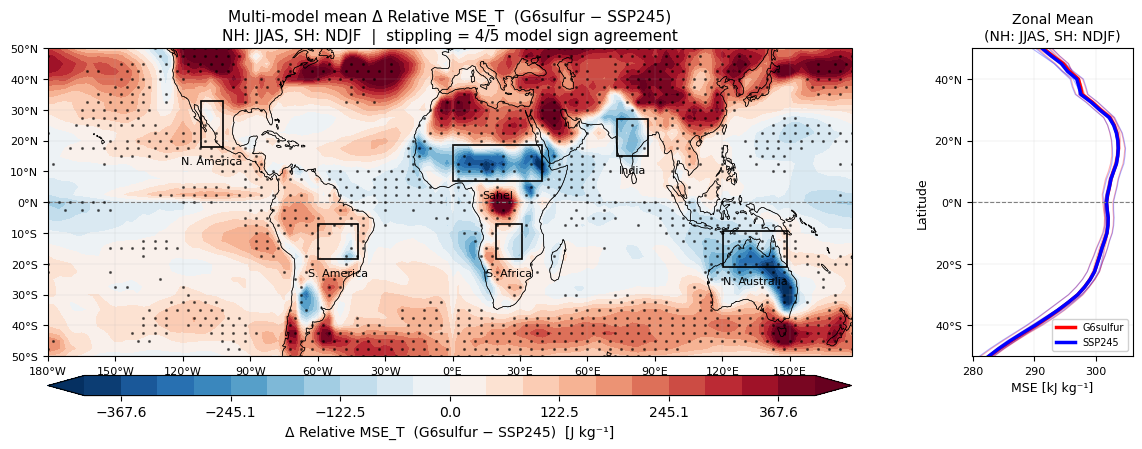

Figure saved → MSE_T_map_with_line_G6sulfur20212100_minus_SSP24520212100.png
Returning → MSE_T_map_with_line_G6sulfur20212100_minus_SSP24520212100


In [14]:
delta_mean, stipple_mask = compute_regional_map_with_zonal_mean(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    agreement_threshold=4,   # 3/4 models
    save_fig=True
)